**DSA506 - Visual Analytics and Communications**  
**Final Test - Problem 2**  
**Michelle Richardson**  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import plotly.express as px
from IPython.display import HTML
import yfinance as yf


I chose the SP&P 500 Index, crude oil and bitcoin for my plots. The inline animations are disabled due to the build latency and file size, but the plots can be found in the Problem2Plots folder.  

In [11]:
plot_path = 'Problem2Plots'   # HTML plots stored here

In [12]:
# Source Yahoo Finance
sp500 = yf.download("^GSPC", period="1y")
crude = yf.download("CL=F", period="1y")
ethereum = yf.download("ETH-USD", period="1y")    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Helper function for the box placement.

In [13]:
def add_event(date, label, y_offset=150):
    idx = sp500.index.get_loc(date)
    x = sp500.index[idx]
    y = sp500["High"].iloc[idx]["^GSPC"]

    dot, = ax.plot(x, y, 'o', color='red', markersize=7)

    text = ax.text(
        x, y + y_offset,
        label,
        ha='center',
        fontsize=10,
        color='red',
        weight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
    )

    return dot, text

# S&P 500 Index

In [14]:
sp500.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-07-23,6358.910156,6360.640137,6317.490234,6326.899902,5642510000
2025-07-24,6363.350098,6381.310059,6360.569824,6368.600098,5282720000
2025-07-25,6388.640137,6395.819824,6368.529785,6370.009766,4470720000
2025-07-28,6389.770020,6401.069824,6375.790039,6397.689941,4565620000
2025-07-29,6370.859863,6409.259766,6363.919922,6405.620117,5076120000


In [15]:
sp500.describe()


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,6894.960239,6925.743172,6859.015253,6894.007128,5.376259e+09
std,354.689216,354.640211,352.676009,352.685592,9.258844e+08
min,6238.009766,6287.279785,6212.689941,6271.709961,1.798270e+09
25%,6640.065186,6679.790039,6608.160156,6644.149902,4.960245e+09
50%,6843.220215,6877.279785,6810.430176,6837.390137,5.307580e+09
75%,7117.600098,7142.135010,7079.479980,7117.924805,5.731650e+09
max,7609.779785,7620.899902,7582.990234,7605.310059,1.002582e+10


Static Plot - SP500

<Axes: title={'center': 'S&P100 - 1 year'}, xlabel='Date'>

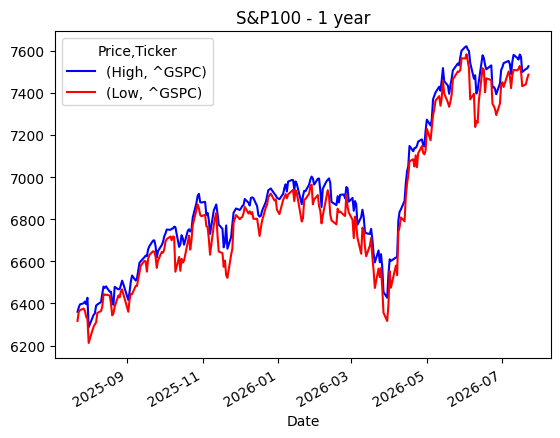

In [16]:
sp500.plot(y=['High','Low'], title='S&P100 - 1 year', color=['blue','red'])

Animation Plot

In [40]:
sp500_events = {

    "2025-10-15": "Tariff uncertainty",
    "2025-11-20": "AI Bubble Fears",
    "2026-02-17": "Inflation Concerns",
    "2026-03-20": "Iran Conflict / Oil Prices",
    "2026-05-15": "Earnings Optimism"
}

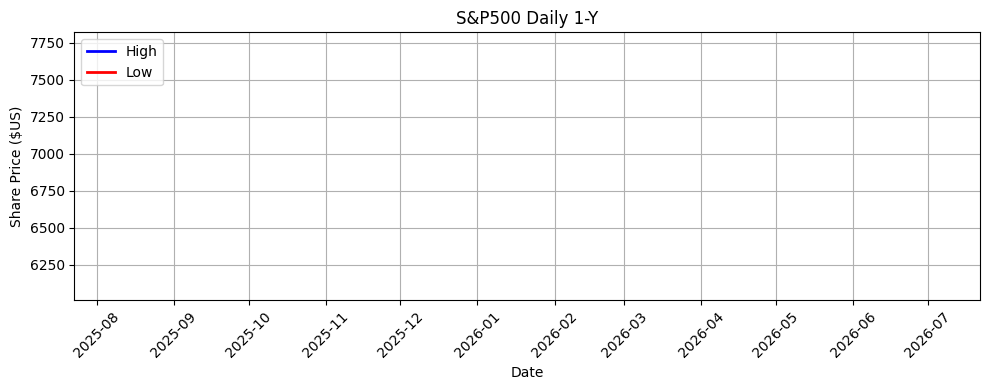

In [47]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('S&P500 Daily 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Share Price ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color='blue', linewidth=2, label='High')
low_line, = ax.plot([], [], color='red', linewidth=2, label='Low')

oct15 = None
nov20 = None
feb17 = None
mar20 = None
may15 = None

ax.legend(loc='upper left')

y_min = sp500['Low']['^GSPC'].min() - 200
y_max = sp500['High']['^GSPC'].max() + 200
ax.set_ylim(y_min, y_max)
ax.set_xlim(sp500.index.min(), sp500.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    global oct15, nov20, feb17, mar20, may15

    high_line.set_data(
        sp500.index[:frame+1],
        sp500["High"].iloc[:frame+1]
    )

    low_line.set_data(
        sp500.index[:frame+1],
        sp500["Low"].iloc[:frame+1]
    )

    events = [high_line, low_line]

    if frame == sp500.index.get_loc('2025-10-15') and oct15 is None:
        oct15 = ax.text(
            sp500.index[sp500.index.get_loc('2025-10-15')], 7200, "Tariff Uncertainty",
            ha='center',va='center',
            fontsize=10, color='blue', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='blue')
        )
        events.append(oct15)

    if frame == sp500.index.get_loc('2025-11-20') and nov20 is None:
        nov20 = ax.text(
            sp500.index[sp500.index.get_loc('2025-11-20')], 6250, "AI Bubble Fears",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        events.append(nov20)

    if frame == sp500.index.get_loc('2026-02-17') and feb17 is None:
        feb17 = ax.text(
            sp500.index[sp500.index.get_loc('2026-02-17')], 7250, "Inflation Concerns",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        events.append(feb17)

    if frame == sp500.index.get_loc('2026-03-20') and mar20 is None:
        mar20 = ax.text(
            sp500.index[sp500.index.get_loc('2026-03-20')], 6200, "Iran Conflict / Oil Prices",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        events.append(mar20)

    if frame == sp500.index.get_loc('2026-05-15') and may15 is None:
        may15 = ax.text(
            sp500.index[sp500.index.get_loc('2026-05-15')], 6600, "Earnings Optimism",
            ha='center',va='center',
            fontsize=10, color='blue', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='blue')
        )
        events.append(mar20)



    return tuple(events)

ani = FuncAnimation(
    fig,
    update,
    frames=len(sp500),
    interval=50,
    blit=True
)

plt.tight_layout()
plt.show()

In [48]:
filename = f'{plot_path}/sp500_1Y.gif'
ani.save(filename, writer='pillow')

In [50]:
# Enable to animate inline
#HTML(ani.to_jshtml())

The S&P500 index shows volatility in the mid-October to mid-November time frame due to uncertainy over tariff policies and their effects. In the fourth week of November, there was a drop due to concerns of an AI bubble. In February, the market started to trend downward due to concerns about inflation and then the US involvement in the conflict with Iran and its impact on oil prices. In mid-May, optimism about earnings caused an upward trend that started to level off and show volatility in June and July.

# Crude Oil 

In [20]:
crude.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2025-07-22,66.209999,67.129997,65.989998,67.120003,269991
2025-07-23,65.250000,65.779999,64.709999,65.489998,251825
2025-07-24,66.029999,66.389999,65.330002,65.419998,281209
2025-07-25,65.160004,66.739998,65.000000,66.150002,234283
2025-07-28,66.709999,67.139999,65.050003,65.150002,262038


<Axes: title={'center': 'Crude Oil - 1 year'}, xlabel='Date'>

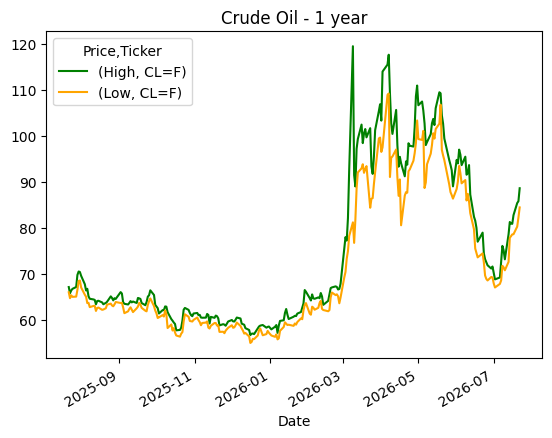

In [21]:
crude_color1 = 'green'
crude_color2 = 'orange'
crude.plot(y=['High','Low'], title='Crude Oil - 1 year', color=[crude_color1,crude_color2])

In [35]:
event_dict = {
    'feb27': ['2026-02-27','US/Israel Strike Iran',140],
    'apr06': ['2026-04-06','OPEC+ announces\nproduction increase',40],
    'jun09': ['2026-06-09','Ceasefire eases\noil fears',140],
    'jul07': ['2026-07-01','Supply risk\nconcerns\nreturn',45]
}

In [36]:
crude.index[crude.index.get_loc(event_dict['jul07'][0])]

Timestamp('2026-07-01 00:00:00')

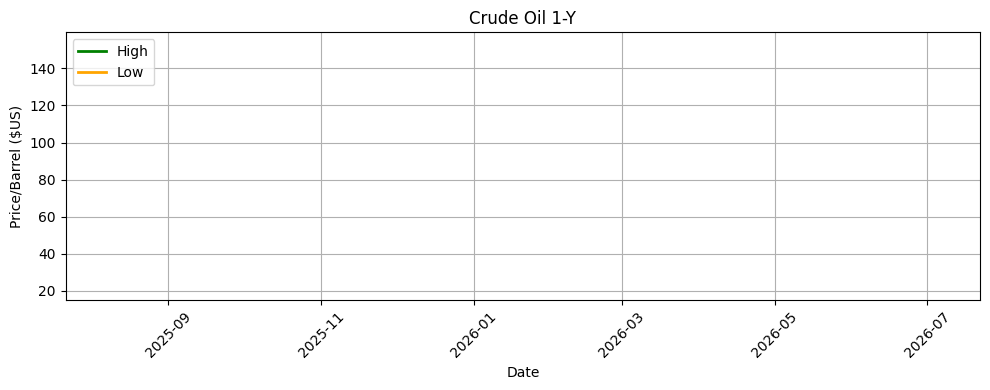

In [37]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('Crude Oil 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Price/Barrel ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color='green', linewidth=2, label='High')
low_line, = ax.plot([], [], color='orange', linewidth=2, label='Low')

event1 = None
event2 = None
event3 = None
event4 = None

ax.legend(loc='upper left')

y_min = crude['Low']['CL=F'].min() - 40
y_max = crude['High']['CL=F'].max() + 40
ax.set_ylim(y_min, y_max)
ax.set_xlim(crude.index.min(), crude.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    global event1, event2, event3, event4

    high_line.set_data(
        crude.index[:frame+1],
        crude['High'].iloc[:frame+1]
    )

    low_line.set_data(
        crude.index[:frame+1],
        crude['Low'].iloc[:frame+1]
    )

    events = [high_line, low_line]

    if frame == crude.index.get_loc(event_dict['feb27'][0]) and event1 is None:
        event1 = ax.text(
            crude.index[crude.index.get_loc(event_dict['feb27'][0])], event_dict['feb27'][2], event_dict['feb27'][1],
            ha='center',va='center',
            fontsize=10, color=crude_color1, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=crude_color1)
        )
        events.append(event1)
   

    if frame == crude.index.get_loc(event_dict['apr06'][0]) and event2 is None:
        event2 = ax.text(
            crude.index[crude.index.get_loc(event_dict['apr06'][0])], event_dict['apr06'][2], event_dict['apr06'][1],
            ha='center',va='center',
            fontsize=10, color=crude_color2, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=crude_color2)
        )
        events.append(event2)

    if frame == crude.index.get_loc(event_dict['jun09'][0]) and event3 is None:
        event3 = ax.text(
            crude.index[crude.index.get_loc(event_dict['jun09'][0])], event_dict['jun09'][2], event_dict['jun09'][1],
            ha='center',va='center',
            fontsize=10, color=crude_color2, weight='bold',
           bbox=dict(facecolor='white',alpha=0.8, edgecolor=crude_color2)
        )
        events.append(event3)

    if frame == crude.index.get_loc(event_dict['jul07'][0]) and event4 is None:
        event4 = ax.text(
            crude.index[crude.index.get_loc(event_dict['jul07'][0])], event_dict['jul07'][2], event_dict['jul07'][1],
            ha='center',va='center',
            fontsize=10, color=crude_color1, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=crude_color1)
        )
        events.append(event4)

    return tuple(events)


ani = FuncAnimation(
    fig,
    update,
    frames=len(crude),
    interval=50,
    blit=True
)
plt.tight_layout()
plt.show()

In [38]:
filename = f'{plot_path}/crude_1Y.gif'
ani.save(filename, writer='pillow')

In [51]:
# Enable to animate inline
#HTML(ani.to_jshtml())

Crude oil trades between 60-70 $US per barrel for the most part, until late February when the US/Israel strike on Iran caused prices to spike. When OPEC announces a production increase, the price drops. A ceasefire in early June reduces pressure and prices drop, but rise again in early July after tensions re-escalate. 

# Cryptocurrency - Ethereum

In [119]:
ethereum.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2025-07-22,3749.145508,3798.100342,3624.140381,3762.882080,45248868820
2025-07-23,3629.703613,3765.026367,3532.856445,3749.238525,41283228953
2025-07-24,3708.005615,3771.381592,3514.999268,3629.731689,40377960354
2025-07-25,3727.266846,3744.820068,3579.962891,3708.005615,42264509577
2025-07-26,3741.395996,3789.789795,3702.774170,3727.237305,24635287361


<Axes: title={'center': 'Ethereum - 1 year'}, xlabel='Date'>

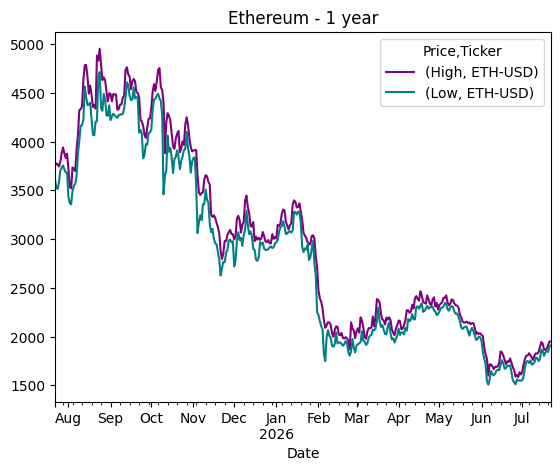

In [120]:
eth_color1 = 'purple'
eth_color2 = 'teal'
ethereum.plot(y=['High','Low'], title='Ethereum - 1 year', color=[eth_color1,eth_color2])

In [169]:
event_dict = {
    'oct10': ['2025-10-10','Tariff fears\nspark crypto selloff',2500],
    'jan20': ['2026-01-20','Crypto policy\noptimism',4000],
    'feb05': ['2026-02-05','Risk assets\ndecline',1250],
    'jun04': ['2026-06-04','Crypto market selloff',3000]
}

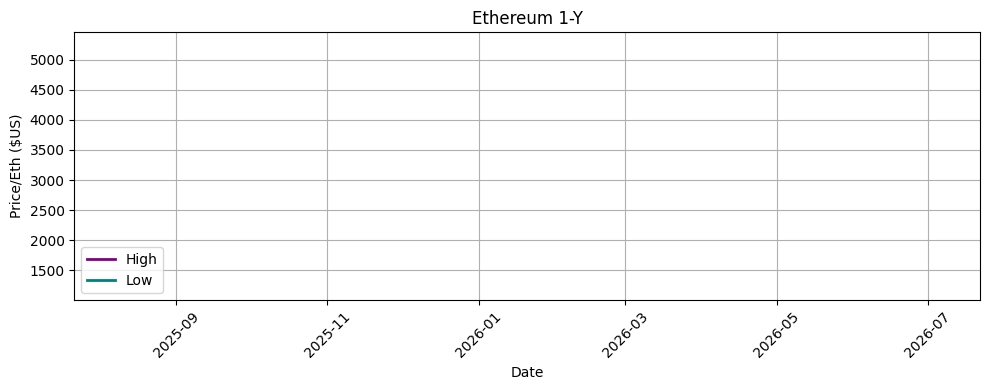

In [170]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('Ethereum 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Price/Eth ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color=eth_color1, linewidth=2, label='High')
low_line, = ax.plot([], [], color=eth_color2, linewidth=2, label='Low')

event1 = None
event2 = None
event3 = None
event4 = None

ax.legend(loc='lower left')

y_min = ethereum['Low']['ETH-USD'].min() - 500
y_max = ethereum['High']['ETH-USD'].max() + 500
ax.set_ylim(y_min, y_max)
ax.set_xlim(ethereum.index.min(), ethereum.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    global event1, event2, event3, event4

    high_line.set_data(
        ethereum.index[:frame+1],
        ethereum['High'].iloc[:frame+1]
    )

    low_line.set_data(
        ethereum.index[:frame+1],
        ethereum['Low'].iloc[:frame+1]
    )

    events = [high_line, low_line]

    if frame == ethereum.index.get_loc(event_dict['oct10'][0]) and event1 is None:
        event1 = ax.text(
            ethereum.index[ethereum.index.get_loc(event_dict['oct10'][0])], event_dict['oct10'][2], event_dict['oct10'][1],
            ha='center',va='center',
            fontsize=10, color=eth_color2, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=eth_color2)
        )
        events.append(event1)
   

    if frame == ethereum.index.get_loc(event_dict['jan20'][0]) and event2 is None:
        event2 = ax.text(
            ethereum.index[ethereum.index.get_loc(event_dict['jan20'][0])], event_dict['jan20'][2], event_dict['jan20'][1],
            ha='center',va='center',
            fontsize=10, color=eth_color1, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=eth_color1)
        )
        events.append(event2)

    if frame == ethereum.index.get_loc(event_dict['feb05'][0]) and event3 is None:
        event3 = ax.text(
            ethereum.index[ethereum.index.get_loc(event_dict['feb05'][0])], event_dict['feb05'][2], event_dict['feb05'][1],
            ha='center',va='center',
            fontsize=10, color=eth_color2, weight='bold',
           bbox=dict(facecolor='white',alpha=0.8, edgecolor=eth_color2)
        )
        events.append(event3)

    if frame == ethereum.index.get_loc(event_dict['jun04'][0]) and event4 is None:
        event4 = ax.text(
            ethereum.index[ethereum.index.get_loc(event_dict['jun04'][0])], event_dict['jun04'][2], event_dict['jun04'][1],
            ha='center',va='center',
            fontsize=10, color=eth_color2, weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor=eth_color2)
        )
        events.append(event4)

    return tuple(events)


ani = FuncAnimation(
    fig,
    update,
    frames=len(ethereum),
    interval=50,
    blit=True
)
plt.tight_layout()
plt.show()

In [171]:
filename = f'{plot_path}/ethereum_1Y.gif'
ani.save(filename, writer='pillow')

In [173]:
# Enable to animate inline
#HTML(ani.to_jshtml())

Cryptocurrency has a tendency to be more volatile and less specific than the indices and commodities due to the inherent risk. In October, concerns about tariffs encouraged a selloff, however optimism cased an upward trend in late December/early January. A significant drop occured in late January to early February due to a general decline in riskier assets. In late May/early June, another selloff occured, and after a bounce, prices dropped back to their lowest levels in the past year. 